Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")


df = pd.read_pickle("../data/features_v2.pkl")
df = df.drop(columns=["embedding"])

with open("../models/model_v3.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer, get_vectorized_features_and_label

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
from python_editor.feature_generation_v2 import TRANSFORMED_FEATURES, LOG_FEATURES

X_test, y_test = get_vectorized_features_and_label(test, TRANSFORMED_FEATURES)

Get predictions

In [4]:
y_pred = model.predict(X_test)

The asymmetry in residuals is back (from -8 to 6)

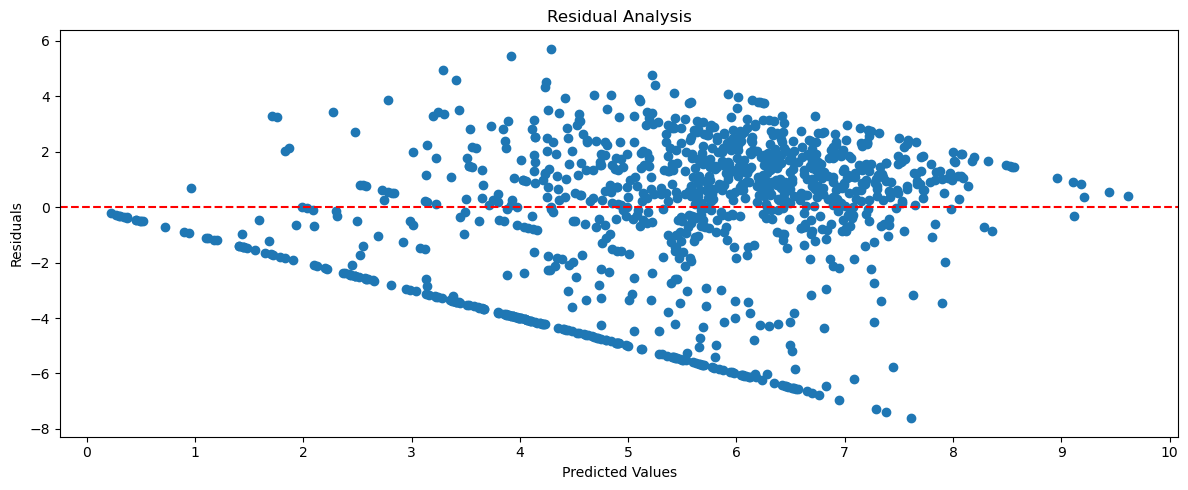

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [8]:
test.loc[:, "error"] = y_test - y_pred

We examine top performing, most over estimated and most under estimated examples

In [9]:
import numpy as np
from python_editor.model_evaluation import get_top_k

test_og = test.copy()
test_og.loc[:, LOG_FEATURES] = np.expm1(test_og[LOG_FEATURES])

top_performing, most_over_estimated, most_under_estimated = get_top_k(test_og, "error", 3)

to_display = TRANSFORMED_FEATURES + ["pylint_score", "error"]
pd.set_option("display.max_columns", None)

Top performing examples have:

1- No bad names

2- No docstring

In [11]:
top_performing[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1031,379.0,0.777778,16.003826,4.0,0.0,0.0,0.000000,0.0,0.142857,0.142857,0.0,0.142857,1.0,0.0,0.0,4.285714,-0.000647
87,2371.0,0.844828,23.788163,1.0,0.0,0.0,0.285714,1.0,0.040816,0.020408,0.0,0.000000,0.0,0.0,0.0,5.714286,0.007468
3423,739.0,0.772727,24.921607,2.0,0.0,0.0,0.000000,0.0,0.058824,0.176471,0.0,0.058824,3.0,0.5,0.0,5.000000,0.009702


Overestimated examples have:

1- Average to high number of characters

2- Docstring

In [12]:
most_over_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
2970,13677.0,0.770833,21.027213,6.0,0.0,1.0,0.070946,1.0,0.094595,0.037162,1.0,0.003378,11.0,1.00,0.0,0.0,-7.615609
239,10891.0,0.888889,20.694417,11.0,0.0,1.0,0.098214,1.0,0.102679,0.062500,0.0,0.008929,6.5,0.25,0.0,0.0,-7.379780
1692,1210.0,0.707317,17.605061,2.0,0.0,1.0,0.068966,1.0,0.137931,0.068966,0.0,0.034483,2.0,1.00,0.0,0.0,-7.290793


Underestimated examples have: 

1- Average to low number of characters

2- No functions/classes

In [14]:
most_under_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1033,1022.0,0.741935,25.702162,0.0,0.0,0.0,0.565217,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,10.000000,5.711873
364,1298.0,1.000000,15.886172,0.0,0.0,0.0,0.032258,0.0,0.032258,0.0,0.0,0.0,0.0,0.0,0.0,9.375000,5.454523
596,840.0,0.750000,17.879224,0.0,0.0,0.0,0.833333,0.0,0.055556,0.0,0.0,0.0,0.0,0.0,0.0,8.235294,4.946215


Feature importance shows that the model relies on continous features more than discrete ones

In [17]:
from python_editor.model_evaluation import get_feature_importance


embedding_dim = 0

importance_df = get_feature_importance(model, embedding_dim, TRANSFORMED_FEATURES)
importance_df

,feature,importance
2,line_length_std,0.161055
0,characters,0.137061
8,variable_density,0.110469
1,code_compactness,0.104733
6,comment_ratio,0.102019
9,func_density,0.071398
11,class_density,0.070065
3,cyclomatic_complexity,0.059362
13,func_class_docstring_ratio,0.051481
12,avg_class_methods,0.032051


In [18]:
X_train, y_train = get_vectorized_features_and_label(train, TRANSFORMED_FEATURES)

100%|===================| 1057/1060 [02:25<00:00]        

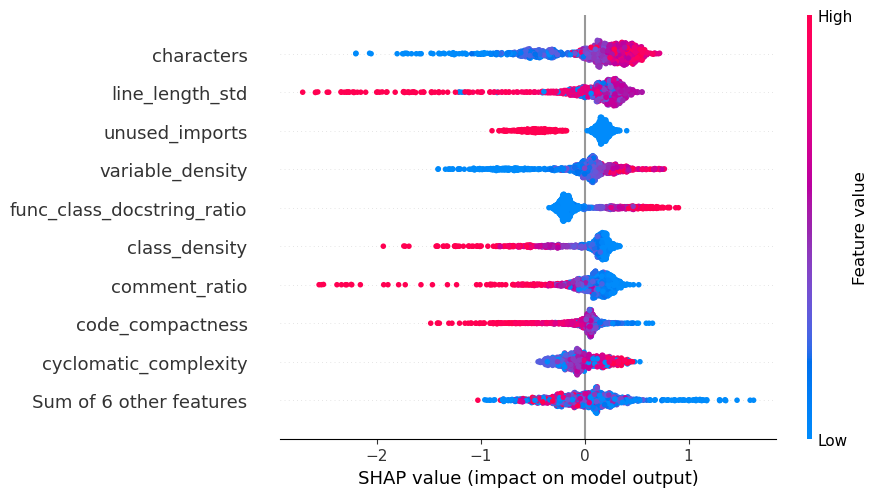

In [19]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, embedding_dim, TRANSFORMED_FEATURES, X_train, X_test)
shap.plots.beeswarm(shap_values)

Our model is now 8x faster than Pylint. Although we lost some performance it was worth it.

In [20]:
from python_editor.model_v3 import get_model_prediction_from_text
from python_editor.data_processing import get_pylint_text
from python_editor.model_evaluation import compare_time

compare_time(get_model_prediction_from_text, get_pylint_text, test["text"][0:50])

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:00<00:00,  1.20s/it]


{'model_time': 0.12556966304779052, 'pylint_time': 1.0753948450088502}